In [2]:
! pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.7 MB/s eta 0:00:00a 0:00:01


In [3]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
model = YOLO('yolo11n.pt')

In [6]:
results = model.train(
    data='african-wildlife.yaml',
    epochs=30, imgsz=640, batch=32, device=0, project='/kaggle/working/runs', name='wildlife'
)

Ultralytics 8.4.53 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=african-wildlife.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=wildlife, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspec

In [8]:
metrics = model.val()

Ultralytics 8.4.53 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1959.6±1711.6 MB/s, size: 101.8 KB)
val: Scanning /kaggle/working/datasets/african-wildlife/labels/val.cache... 225 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 225/225 62.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 5.8it/s 2.6s0.1s
                   all        225        379      0.944      0.899      0.954      0.792
               buffalo         62         89      0.938      0.888      0.951      0.806
              elephant         53         91      0.897      0.857      0.939      0.782
                 rhino         55         85      0.953       0.95      0.964      0.839
                 zebra         59        114      0.989      0.904       0.96      0.742
Speed: 1.2ms prep

In [9]:
metrics.box.map50

np.float64(0.9536757105815112)

In [19]:
preds = model.predict(
    source = '/kaggle/working/datasets/african-wildlife/images/test', conf=0.8, save=True,project='/kaggle/working/runs', name='wildlife_test' 
)


image 1/227 /kaggle/working/datasets/african-wildlife/images/test/1 (103).jpg: 544x640 1 buffalo, 10.4ms
image 2/227 /kaggle/working/datasets/african-wildlife/images/test/1 (121).jpg: 512x640 (no detections), 8.7ms
image 3/227 /kaggle/working/datasets/african-wildlife/images/test/1 (128).jpg: 416x640 1 buffalo, 8.9ms
image 4/227 /kaggle/working/datasets/african-wildlife/images/test/1 (130).jpg: 448x640 1 buffalo, 8.8ms
image 5/227 /kaggle/working/datasets/african-wildlife/images/test/1 (131).jpg: 480x640 1 buffalo, 8.4ms
image 6/227 /kaggle/working/datasets/african-wildlife/images/test/1 (137).jpg: 640x448 (no detections), 8.6ms
image 7/227 /kaggle/working/datasets/african-wildlife/images/test/1 (144).jpg: 448x640 1 buffalo, 8.4ms
image 8/227 /kaggle/working/datasets/african-wildlife/images/test/1 (154).jpg: 480x640 1 buffalo, 8.0ms
image 9/227 /kaggle/working/datasets/african-wildlife/images/test/1 (168).jpg: 448x640 1 buffalo, 8.5ms
image 10/227 /kaggle/working/datasets/african-wild

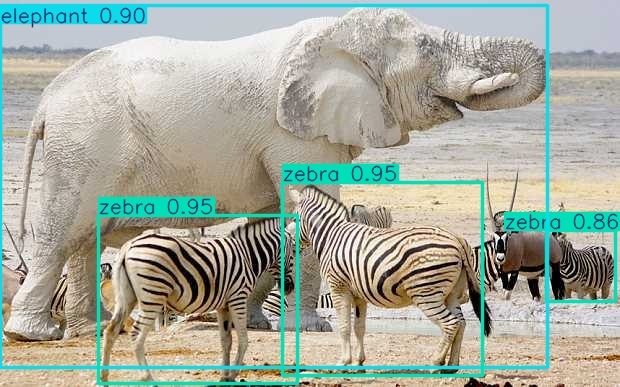

In [20]:
from IPython.display import Image
import glob

Image(filename=sorted(glob.glob('/kaggle/working/runs/wildlife_test-3/*.jpg'))[78])

In [21]:
from pathlib import Path
from PIL import Image
import torch, torch.nn as nn, torchvision as tv
from torch.utils.data import Dataset, DataLoader

ROOT = Path('datasets/african-wildlife')
tfm = tv.transforms.Compose([
    tv.transforms.Resize(256), tv.transforms.CenterCrop(224),
    tv.transforms.ToTensor(),
    tv.transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

class AWCls(Dataset):
    def __init__(self, split):
        self.items = []
        for lbl in sorted((ROOT/'labels'/split).iterdir()):
            rows = [r for r in lbl.read_text().splitlines() if r.strip()]
            if not rows: continue
            img = ROOT/'images'/split/(lbl.stem+'.jpg')
            if img.exists():
                self.items.append((img, int(rows[0].split()[0])))
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        p, c = self.items[i]
        return tfm(Image.open(p).convert('RGB')), c

train_loader = DataLoader(AWCls('train'), batch_size=32, shuffle=True, num_workers=2)
test_loader  = DataLoader(AWCls('test'),  batch_size=64, num_workers=2)

In [22]:
device = 'cuda'

In [23]:
cnn = tv.models.resnet18(weights=tv.models.ResNet18_Weights.DEFAULT)
cnn.fc = nn.Linear(cnn.fc.in_features, 4)
cnn = cnn.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 165MB/s] 


In [25]:
opt = torch.optim.AdamW(cnn.parameters(), lr=3e-4)
crit = nn.CrossEntropyLoss()

In [30]:
for _ in range(5):
    cnn.train()
    for x, y in train_loader:
        opt.zero_grad()
        pred = cnn(x.to(device))
        crit(pred, y.to(device)).backward()
        opt.step()

In [32]:
cnn.eval()
corr = 0
n = 0
with torch.no_grad():
    for x, y in test_loader:
        pred = cnn(x.to(device)).argmax(1).cpu()
        corr += (pred == y).sum().item()
        n += y.numel()

cnn_acc = corr / n
cnn_acc

0.9779735682819384

In [35]:
import time, glob

def fps(fn, n=50, warmup=5):
    for _ in range(warmup): fn()
    torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(n): fn()
    torch.cuda.synchronize()
    return n / (time.time() - t0)

x_dummy, _ = next(iter(test_loader)); x_dummy = x_dummy[:1].to(device)
cnn_fps  = fps(lambda: cnn(x_dummy))

test_img = sorted(glob.glob(str(ROOT/'images/test/*.jpg')))[0]
yolo_fps = fps(lambda: model(test_img, verbose=False, device=device))
cnn_fps, yolo_fps

(281.01108419269775, 77.12953291651343)

In [37]:
import pandas as pd

In [38]:
pd.DataFrame({
    'model':    ['ResNet18', 'YOLO11n'],
    'output':   ['class only', 'class + bbox'],
    'metric':   [f'acc {cnn_acc:.3f}', f'mAP50 {metrics.box.map50:.3f}'],
    'FPS (T4)': [f'{cnn_fps:.1f}', f'{yolo_fps:.1f}'],
})

,model,output,metric,FPS (T4)
0,ResNet18,class only,acc 0.978,281.0
1,YOLO11n,class + bbox,mAP50 0.954,77.1
